# MoCap Data Exploreation (Converted 3JS Format)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import ijson
import numpy as np 
import matplotlib.pyplot as plt

from src.utils import print_json_structure

---
## Load & Re-Save Data

Re-save each clip as separated npz file instead of one large json for quick load.

In [3]:
DATA_PATH = "data/justsigns-recorder.animation_clips.json"

clip_count = 0

with open(DATA_PATH, "rb") as f:
    for i, clip in enumerate(ijson.items(f, "item")):
        sys.stdout.write(f"\rprocessing clip {i} ...")
        sys.stdout.flush()
        np.savez_compressed(f"data/npz/clip_{i}.npz", clip=clip, allow_pickle=True)
        clip_count += 1

print(f"\nfinished: {clip_count} saved as separate npz's")

processing clip 482 ...
finished: 483 saved as separate npz's


for the record: the above cell took 6m 2.1s to finish

---
## Clip Structure

In [4]:
CLIP_IDX = 67

data = np.load(f"data/npz/clip_{CLIP_IDX}.npz", allow_pickle=True)
clip = data["clip"].item()

In [5]:
print_json_structure(clip)

_id: 
    $oid: str
animationClip: 
    name: str
    duration: Decimal
    tracks: list of dict
    uuid: str
    blendMode: int
recordDate: int


In [6]:
anim = clip["animationClip"]

clip_name = anim["name"]
clip_duration = anim["duration"]
tracks = anim["tracks"]

print(f"name        = {clip_name}")
print(f"duration    = {clip_duration}")
print(f"# of tracks = {len(tracks)}")
print("\ntrack structure:")
print_json_structure(tracks[0], level=1)

name        = เหตุผล-1726385790025
duration    = 5.5700999999940315
# of tracks = 671

track structure:
    name: str
    times: list of int
    values: list of Decimal
    type: str


In [7]:
# there are 2 types of track: quaternion and morphTargetInfluences

quat_names = []
morph_names = []
null_names = []

for track in tracks:
    if "quaternion" in track["name"]:
        quat_names.append(track["name"])
    elif "morphTargetInfluences" in track["name"]:
        morph_names.append(track["name"])
    else:
        null_names.append(track["name"])

print(f"{len(quat_names)} quaternion tracks")
print(f"{len(morph_names)} morphTargetInfluences tracks")
print(f"{len(null_names)} others")

47 quaternion tracks
624 morphTargetInfluences tracks
0 others


note:
- 47 quaternion tracks
- 624 morphTargetInfluences tracks
- some clips does not have morphTargetInfluences tracks (no face tracking)

In [8]:
quat_names

['rootx.quaternion',
 'spine_01x.quaternion',
 'spine_02x.quaternion',
 'neckx.quaternion',
 'headx.quaternion',
 'shoulderr.quaternion',
 'arm_stretchr.quaternion',
 'forearm_stretchr.quaternion',
 'handr.quaternion',
 'thumb1r.quaternion',
 'thumb2r.quaternion',
 'index1r.quaternion',
 'index2r.quaternion',
 'index3r.quaternion',
 'middle1r.quaternion',
 'middle2r.quaternion',
 'middle3r.quaternion',
 'ring1r.quaternion',
 'ring2r.quaternion',
 'ring3r.quaternion',
 'pinky1r.quaternion',
 'pinky2r.quaternion',
 'pinky3r.quaternion',
 'shoulderl.quaternion',
 'arm_stretchl.quaternion',
 'forearm_stretchl.quaternion',
 'handl.quaternion',
 'thumb1l.quaternion',
 'thumb2l.quaternion',
 'index1l.quaternion',
 'index2l.quaternion',
 'index3l.quaternion',
 'middle1l.quaternion',
 'middle2l.quaternion',
 'middle3l.quaternion',
 'ring1l.quaternion',
 'ring2l.quaternion',
 'ring3l.quaternion',
 'pinky1l.quaternion',
 'pinky2l.quaternion',
 'pinky3l.quaternion',
 'thigh_stretchl.quaternion',
 

---
## Exploring Values Properties

In [9]:
# checking frames count consistency

N_TRACKS = len(tracks)

n_frames = np.empty(shape=(N_TRACKS))

for i, track in enumerate(tracks):
    n_frames[i] = len(track["times"])

np.unique_counts(n_frames)

UniqueCountsResult(values=array([  2.,  64.,  95., 209., 244., 275., 298., 304.]), counts=array([ 84,  12,  24,  24,  12,  24, 444,  47]))

In [10]:
for track in tracks:
    if len(track["times"]) == 2:
        print(track["name"])

Alex_body_1.morphTargetInfluences[22]
Alex_body_1.morphTargetInfluences[44]
Alex_body_1.morphTargetInfluences[45]
Alex_body_1.morphTargetInfluences[3]
Alex_body_1.morphTargetInfluences[26]
Alex_body_1.morphTargetInfluences[25]
Alex_body_1.morphTargetInfluences[16]
Alex_body_2.morphTargetInfluences[22]
Alex_body_2.morphTargetInfluences[44]
Alex_body_2.morphTargetInfluences[45]
Alex_body_2.morphTargetInfluences[3]
Alex_body_2.morphTargetInfluences[26]
Alex_body_2.morphTargetInfluences[25]
Alex_body_2.morphTargetInfluences[16]
Alex_eyebrows.morphTargetInfluences[22]
Alex_eyebrows.morphTargetInfluences[44]
Alex_eyebrows.morphTargetInfluences[45]
Alex_eyebrows.morphTargetInfluences[3]
Alex_eyebrows.morphTargetInfluences[26]
Alex_eyebrows.morphTargetInfluences[25]
Alex_eyebrows.morphTargetInfluences[16]
Alex_iris_left_1.morphTargetInfluences[22]
Alex_iris_left_1.morphTargetInfluences[44]
Alex_iris_left_1.morphTargetInfluences[45]
Alex_iris_left_1.morphTargetInfluences[3]
Alex_iris_left_1.mor

In [11]:
# checking frames count consistency (qunts only)

N_QUAT_TRACKS = len(quat_names)

n_quat_frames = np.empty(shape=(N_QUAT_TRACKS))
i = 0

for track in tracks:
    if track["name"] in quat_names:
        n_quat_frames[i] = len(track["times"])
        i += 1

np.unique_counts(n_quat_frames)

UniqueCountsResult(values=array([304.]), counts=array([47]))

note:

- quaternion tracks have consistance number of frames,
- blendshape tracks don't

In [12]:
# check timing consistency (quats only)

times = np.empty(shape=(N_QUAT_TRACKS, int(n_quat_frames[0])))
i = 0

for track in tracks:
    if track["name"] in quat_names:
        times[i] = track["times"]
        i += 1

for frame in times.T:
    print(np.unique(frame))

[0.]
[0.0152]
[0.0433]
[0.0611]
[0.077]
[0.0923]
[0.108]
[0.1227]
[0.1366]
[0.15180001]
[0.1698]
[0.1822]
[0.20999999]
[0.2245]
[0.2378]
[0.25240001]
[0.2656]
[0.28080001]
[0.3057]
[0.3195]
[0.33649999]
[0.35730001]
[0.36840001]
[0.38229999]
[0.41080001]
[0.4244]
[0.43970001]
[0.45640001]
[0.47009999]
[0.4867]
[0.50220001]
[0.5205]
[0.5377]
[0.5528]
[0.57010001]
[0.5844]
[0.60049999]
[0.61379999]
[0.64120001]
[0.65710002]
[0.67199999]
[0.68650001]
[0.70380002]
[0.72100002]
[0.73430002]
[0.74970001]
[0.76599997]
[0.78299999]
[0.79720002]
[0.81580001]
[0.82880002]
[0.84789997]
[0.87709999]
[0.89249998]
[0.91509998]
[0.92570001]
[0.94419998]
[0.9756]
[0.98769999]
[1.00269997]
[1.01760006]
[1.03639996]
[1.04980004]
[1.06739998]
[1.08150005]
[1.09850001]
[1.11170006]
[1.12820005]
[1.14240003]
[1.17410004]
[1.19369996]
[1.20799994]
[1.23930001]
[1.2536]
[1.27119994]
[1.28859997]
[1.30540001]
[1.32169998]
[1.33729994]
[1.35169995]
[1.36590004]
[1.38419998]
[1.40100002]
[1.41460001]
[1.4270999

note:

- The same frame have same timestamp for every quaternion tracks

In [13]:
# checking qunts values

sample = tracks[-9] # pinky1l
times  = sample["times"]
values = sample["values"]

print(len(times), len(values))

304 1216


In [14]:
quats = np.reshape(values, shape=(len(times), 4)).astype(float)

quats

array([[ 0.31513223, -0.01667108, -0.01197926, -0.94882566],
       [ 0.31544507, -0.01724593, -0.01194596, -0.94871181],
       [ 0.31544507, -0.01724593, -0.01194596, -0.94871181],
       ...,
       [ 0.23862174,  0.01847648, -0.05005181, -0.96964574],
       [ 0.2395408 ,  0.01944122, -0.04884083, -0.96946198],
       [ 0.2395408 ,  0.01944122, -0.04884083, -0.96946198]],
      shape=(304, 4))

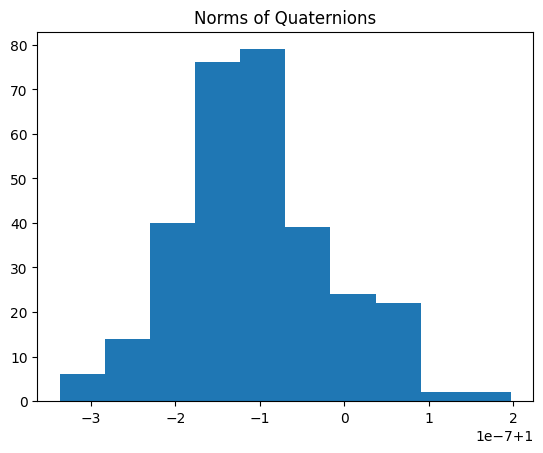

In [15]:
# check normalization of quats

norms = np.linalg.norm(quats, axis=1)

plt.hist(norms)
plt.title("Norms of Quaternions")
plt.show()

## Parse Clip Tracks to a More Convenience Format

Demo of a function -> implemented in src.utils

In [16]:
tracks = clip["animationClip"]["tracks"]

In [17]:
new_tracks = {}

for track in tracks:
    new_tracks[track["name"]] = {
        "type": track["type"],
        "times": track["times"],
        "values": track["values"],
    }

In [18]:
new_tracks.keys()

dict_keys(['Alex_body_1.morphTargetInfluences[19]', 'Alex_body_1.morphTargetInfluences[38]', 'Alex_body_1.morphTargetInfluences[41]', 'Alex_body_1.morphTargetInfluences[15]', 'Alex_body_1.morphTargetInfluences[17]', 'Alex_body_1.morphTargetInfluences[28]', 'Alex_body_1.morphTargetInfluences[27]', 'Alex_body_1.morphTargetInfluences[1]', 'Alex_body_1.morphTargetInfluences[8]', 'Alex_body_1.morphTargetInfluences[2]', 'Alex_body_1.morphTargetInfluences[48]', 'Alex_body_1.morphTargetInfluences[18]', 'Alex_body_1.morphTargetInfluences[23]', 'Alex_body_1.morphTargetInfluences[24]', 'Alex_body_1.morphTargetInfluences[36]', 'Alex_body_1.morphTargetInfluences[22]', 'Alex_body_1.morphTargetInfluences[37]', 'Alex_body_1.morphTargetInfluences[21]', 'Alex_body_1.morphTargetInfluences[35]', 'Alex_body_1.morphTargetInfluences[32]', 'Alex_body_1.morphTargetInfluences[20]', 'Alex_body_1.morphTargetInfluences[31]', 'Alex_body_1.morphTargetInfluences[34]', 'Alex_body_1.morphTargetInfluences[33]', 'Alex_bo

In [19]:
new_tracks['rootx.quaternion']["type"]

'quaternion'

In [20]:
from src.utils import parse_clip

test = parse_clip(clip)
test["animationClip"]["tracks"]["rootx.quaternion"]["values"]

array([[-0.00742179,  0.00723516, -0.00377498, -0.9999392 ],
       [-0.00737174,  0.00730487, -0.00363197, -0.99993956],
       [-0.00737174,  0.00730487, -0.00363197, -0.99993956],
       ...,
       [-0.00771812,  0.00852309, -0.00417182, -0.99992526],
       [-0.0076954 ,  0.00839715, -0.00417601, -0.99992645],
       [-0.0076954 ,  0.00839715, -0.00417601, -0.99992645]],
      shape=(304, 4))